In [328]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [329]:
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')

mpl.rc('font', family='TH Sarabun New', size=14)

# Data Preparation

In [275]:
people_names = [
    "นางสาววิชุดา ว่องวัฒนวิโรจน์",
    "นางสาวสุวิภา กุศลจูง",
    "นายศรีพรหม หอมยก",
    "นายสมบูรณ์ รูปสะอาด",
    "นายดาชัย เอกปฐพี",
    "นายธนาธร โล่ห์สุนทร",
    "พันเอกสันทัด ภัทรกิตตินนท์",
]
party_names = []
party2number = dict()
with open("../partys_lists_number.txt", 'r', encoding="utf-8") as f:
    lines = []
    for line in f:
        if line.strip() == "":continue
        num, party = line.strip().split(":")
        num = int(num.strip().split()[1])
        party = party.strip().removeprefix("พรรค")
        lines.append(party)
        party2number[party] = num
for i in range(1,8):
    party2number[people_names[i-1]] = i
party_names += lines

In [276]:
df = pd.read_csv("../master_result_clean.csv")
df_1 = pd.read_csv("../master_summary.csv", index_col=0)

In [277]:
print(df.shape)
print(df_1.shape)

(22720, 8)
(710, 10)


In [278]:
df_1

,type,province,district,sub-district,unit_number,total_ballots,valid_ballots,invalid_ballots,no_vote_ballots,remain_ballots
0,บช,ลำปาง,นอกเขต,ชุดที่ 1,-1,700,663,8,29,-1
1,เขต,ลำปาง,นอกเขต,ชุดที่ 1,-1,700,605,32,63,-1
2,บช,ลำปาง,นอกเขต,ชุดที่ 10,-1,700,668,8,24,-1
3,เขต,ลำปาง,นอกเขต,ชุดที่ 10,-1,700,616,28,56,-1
4,บช,ลำปาง,นอกเขต,ชุดที่ 11,-1,700,664,6,30,-1
...,...,...,...,...,...,...,...,...,...,...
705,เขต,ลำปาง,แจ้ห่ม,วิเชตนคร,11,320,209,17,24,70
706,เขต,ลำปาง,แจ้ห่ม,บ้านสา,8,320,215,11,9,85
707,เขต,ลำปาง,งาว,หลวงเหนือ,3,560,325,13,19,203
708,เขต,ลำปาง,นอกเขต,ชุดที่ 5,-1,700,620,26,54,-1


In [279]:
mannual_normalize = df_1.loc[df_1['valid_ballots'] == -1, ['district','sub-district','unit_number', 'type']].values.tolist()

In [280]:
mannual_normalize

[['วังเหนือ', 'ทุ่งฮั้ว', 3, 'เขต'],
 ['วังเหนือ', 'ทุ่งฮั้ว', 2, 'บช'],
 ['เมืองลำปาง', 'บ้านเสด็จ', 8, 'เขต'],
 ['แจ้ห่ม', 'แม่สุก', 2, 'บช']]

In [281]:
df.isnull().sum()

type            0
province        0
district        0
sub-district    0
unit_number     0
name            0
score           0
score_clean     0
dtype: int64

In [282]:
df_groupby = df.groupby(["district", "sub-district", "unit_number",'type', "name"])['score_clean'].sum().unstack("name")

In [283]:
df_groupby.head(10)

name                                    กรีน  กล้าธรรม  ก้าวอิสระ  \
district sub-district unit_number type                              
งาว      นาแก         1           บช     0.0      23.0        0.0   
                                  เขต    NaN       NaN        NaN   
                      2           บช     0.0      74.0        0.0   
                                  เขต    NaN       NaN        NaN   
                      3           บช     0.0      43.0        0.0   
                                  เขต    NaN       NaN        NaN   
                      4           บช     0.0      49.0        0.0   
                                  เขต    NaN       NaN        NaN   
                      5           บช     0.0     118.0        0.0   
                                  เขต    NaN       NaN        NaN   

name                                    ครูไทยเพื่อประชาชน  คลองไทย  \
district sub-district unit_number type                                
งาว      นาแก         1           บช                   0.0      0.0   
                                  เขต                  NaN      NaN   
                      2           บช                   1.0      1.0   
                                  เขต                  NaN      NaN   
                      3           บช                   1.0      1.0   
                                  เขต                  NaN      NaN   
                      4           บช                   1.0      0.0   
                                  เขต                  NaN      NaN   
                      5           บช                   0.0      0.0   
                                  เขต                  NaN      NaN   

name                                    ความหวังใหม่  ทางเลือกใหม่  \
district sub-district unit_number type                               
งาว      นาแก         1           บช             0.0           1.0   
                                  เขต            NaN           NaN   
                      2           บช             1.0           0.0   
                                  เขต            NaN           NaN   
                      3           บช             0.0           1.0   
                                  เขต            NaN           NaN   
                      4           บช             0.0           2.0   
                                  เขต            NaN           NaN   
                      5           บช             0.0           1.0   
                                  เขต            NaN           NaN   

name                                    ท้องที่ไทย  \
district sub-district unit_number type               
งาว      นาแก         1           บช           0.0   
                                  เขต          NaN   
                      2           บช           0.0   
                                  เขต          NaN   
                      3           บช           0.0   
                                  เขต          NaN   
                      4           บช           1.0   
                                  เขต          NaN   
                      5           บช           1.0   
                                  เขต          NaN   

name                                    นางสาววิชุดา ว่องวัฒนวิโรจน์  \
district sub-district unit_number type                                 
งาว      นาแก         1           บช                             NaN   
                                  เขต                            2.0   
                      2           บช                             NaN   
                                  เขต                            6.0   
                      3           บช                             NaN   
                                  เขต                            0.0   
                      4           บช                             NaN   
                                  เขต                            4.0   
                      5           บช                             NaN   
                                  เข

In [284]:
df_groupby.isnull().sum()

name
กรีน                  355
กล้าธรรม              355
ก้าวอิสระ             355
ครูไทยเพื่อประชาชน    355
คลองไทย               355
                     ... 
ไทยพิทักษ์ธรรม        355
ไทยภักดี              355
ไทยรวมไทย             355
ไทยสร้างไทย           355
ไทรวมพลัง             355
Length: 64, dtype: int64

In [285]:
df_groupby = df_groupby.fillna(0)

In [286]:
df_groupby['บช_sum_ball'] = df_groupby[party_names].sum(axis=1)
df_groupby['เขต_sum_ball'] = df_groupby[people_names].sum(axis=1)

In [287]:
df_groupby.head(10)

name                                    กรีน  กล้าธรรม  ก้าวอิสระ  \
district sub-district unit_number type                              
งาว      นาแก         1           บช     0.0      23.0        0.0   
                                  เขต    0.0       0.0        0.0   
                      2           บช     0.0      74.0        0.0   
                                  เขต    0.0       0.0        0.0   
                      3           บช     0.0      43.0        0.0   
                                  เขต    0.0       0.0        0.0   
                      4           บช     0.0      49.0        0.0   
                                  เขต    0.0       0.0        0.0   
                      5           บช     0.0     118.0        0.0   
                                  เขต    0.0       0.0        0.0   

name                                    ครูไทยเพื่อประชาชน  คลองไทย  \
district sub-district unit_number type                                
งาว      นาแก         1           บช                   0.0      0.0   
                                  เขต                  0.0      0.0   
                      2           บช                   1.0      1.0   
                                  เขต                  0.0      0.0   
                      3           บช                   1.0      1.0   
                                  เขต                  0.0      0.0   
                      4           บช                   1.0      0.0   
                                  เขต                  0.0      0.0   
                      5           บช                   0.0      0.0   
                                  เขต                  0.0      0.0   

name                                    ความหวังใหม่  ทางเลือกใหม่  \
district sub-district unit_number type                               
งาว      นาแก         1           บช             0.0           1.0   
                                  เขต            0.0           0.0   
                      2           บช             1.0           0.0   
                                  เขต            0.0           0.0   
                      3           บช             0.0           1.0   
                                  เขต            0.0           0.0   
                      4           บช             0.0           2.0   
                                  เขต            0.0           0.0   
                      5           บช             0.0           1.0   
                                  เขต            0.0           0.0   

name                                    ท้องที่ไทย  \
district sub-district unit_number type               
งาว      นาแก         1           บช           0.0   
                                  เขต          0.0   
                      2           บช           0.0   
                                  เขต          0.0   
                      3           บช           0.0   
                                  เขต          0.0   
                      4           บช           1.0   
                                  เขต          0.0   
                      5           บช           1.0   
                                  เขต          0.0   

name                                    นางสาววิชุดา ว่องวัฒนวิโรจน์  \
district sub-district unit_number type                                 
งาว      นาแก         1           บช                             0.0   
                                  เขต                            2.0   
                      2           บช                             0.0   
                                  เขต                            6.0   
                      3           บช                             0.0   
                                  เขต                            0.0   
                      4           บช                             0.0   
                                  เขต                            4.0   
                      5           บช                             0.0   
                                  เข

In [288]:
df_1.loc[df_1['valid_ballots'] == 0, :]

,type,province,district,sub-district,unit_number,total_ballots,valid_ballots,invalid_ballots,no_vote_ballots,remain_ballots


In [289]:
df_groupby.loc[df_groupby.index.isin(mannual_normalize), :]

name                                      กรีน  กล้าธรรม  ก้าวอิสระ  \
district   sub-district unit_number type                              
วังเหนือ   ทุ่งฮั้ว     2           บช     0.0      26.0        0.0   
                        3           เขต    0.0       0.0        0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต    0.0       0.0        0.0   
แจ้ห่ม     แม่สุก       2           บช     0.0     117.0        0.0   

name                                      ครูไทยเพื่อประชาชน  คลองไทย  \
district   sub-district unit_number type                                
วังเหนือ   ทุ่งฮั้ว     2           บช                   1.0      0.0   
                        3           เขต                  0.0      0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต                  0.0      0.0   
แจ้ห่ม     แม่สุก       2           บช                   0.0      0.0   

name                                      ความหวังใหม่  ทางเลือกใหม่  \
district   sub-district unit_number type                               
วังเหนือ   ทุ่งฮั้ว     2           บช             0.0           3.0   
                        3           เขต            0.0           0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต            0.0           0.0   
แจ้ห่ม     แม่สุก       2           บช             0.0           3.0   

name                                      ท้องที่ไทย  \
district   sub-district unit_number type               
วังเหนือ   ทุ่งฮั้ว     2           บช           0.0   
                        3           เขต          0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต          0.0   
แจ้ห่ม     แม่สุก       2           บช           2.0   

name                                      นางสาววิชุดา ว่องวัฒนวิโรจน์  \
district   sub-district unit_number type                                 
วังเหนือ   ทุ่งฮั้ว     2           บช                             0.0   
                        3           เขต                            6.0   
เมืองลำปาง บ้านเสด็จ    8           เขต                            4.0   
แจ้ห่ม     แม่สุก       2           บช                             0.0   

name                                      นางสาวสุวิภา กุศลจูง  ...  \
district   sub-district unit_number type                        ...   
วังเหนือ   ทุ่งฮั้ว     2           บช                     0.0  ...   
                        3           เขต                   36.0  ...   
เมืองลำปาง บ้านเสด็จ    8           เขต                   96.0  ...   
แจ้ห่ม     แม่สุก       2           บช                     0.0  ...   

name                                      ไทยทรัพย์ทวี  ไทยธรรม  ไทยพร้อม  \
district   sub-district unit_number type                                    
วังเหนือ   ทุ่งฮั้ว     2           บช             5.0      1.0       1.0   
                        3           เขต            0.0      0.0       0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต            0.0      0.0       0.0   
แจ้ห่ม     แม่สุก       2           บช             5.0      0.0       0.0   

name                                      ไทยพิทักษ์ธรรม  ไทยภักดี  ไทยรวมไทย  \
district   sub-district unit_number type                                        
วังเหนือ   ทุ่งฮั้ว     2           บช               0.0       0.0        0.0   
                        3           เขต              0.0       0.0        0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต              0.0       0.0        0.0   
แจ้ห่ม     แม่สุก       2           บช               0.0       2.0        1.0   

name                                      ไทยสร้างไทย  ไทรวมพลัง  บช_sum_ball  \
district   sub-district unit_number type                                        
วังเหนือ   ทุ่งฮั้ว     2           บช            4.0        0.0        377.0   
                        3           เขต           0.0        0.0          0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต           0.0        0.0          0.0   
แจ้ห่ม     แม่สุก       2           บช            0.0        0.0        394.0   

name                                      เขต_sum_ball 

In [290]:
valid_ballots_series = df_1.groupby(['district', 'sub-district', 'unit_number','type'])['valid_ballots'].first()
df_groupby['valid_ball'] = valid_ballots_series


for col in people_names + party_names:
    new_col = col + "_normalize"
    df_groupby[new_col] = df_groupby[col]/df_groupby['valid_ball']
    df_groupby.loc[df_groupby.index.isin(mannual_normalize), new_col] = df_groupby[col]/(df_groupby['บช_sum_ball'] + df_groupby['เขต_sum_ball'])
    

In [291]:
df_groupby.loc[df_groupby.index.isin(mannual_normalize), :]

name                                      กรีน  กล้าธรรม  ก้าวอิสระ  \
district   sub-district unit_number type                              
วังเหนือ   ทุ่งฮั้ว     2           บช     0.0      26.0        0.0   
                        3           เขต    0.0       0.0        0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต    0.0       0.0        0.0   
แจ้ห่ม     แม่สุก       2           บช     0.0     117.0        0.0   

name                                      ครูไทยเพื่อประชาชน  คลองไทย  \
district   sub-district unit_number type                                
วังเหนือ   ทุ่งฮั้ว     2           บช                   1.0      0.0   
                        3           เขต                  0.0      0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต                  0.0      0.0   
แจ้ห่ม     แม่สุก       2           บช                   0.0      0.0   

name                                      ความหวังใหม่  ทางเลือกใหม่  \
district   sub-district unit_number type                               
วังเหนือ   ทุ่งฮั้ว     2           บช             0.0           3.0   
                        3           เขต            0.0           0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต            0.0           0.0   
แจ้ห่ม     แม่สุก       2           บช             0.0           3.0   

name                                      ท้องที่ไทย  \
district   sub-district unit_number type               
วังเหนือ   ทุ่งฮั้ว     2           บช           0.0   
                        3           เขต          0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต          0.0   
แจ้ห่ม     แม่สุก       2           บช           2.0   

name                                      นางสาววิชุดา ว่องวัฒนวิโรจน์  \
district   sub-district unit_number type                                 
วังเหนือ   ทุ่งฮั้ว     2           บช                             0.0   
                        3           เขต                            6.0   
เมืองลำปาง บ้านเสด็จ    8           เขต                            4.0   
แจ้ห่ม     แม่สุก       2           บช                             0.0   

name                                      นางสาวสุวิภา กุศลจูง  ...  \
district   sub-district unit_number type                        ...   
วังเหนือ   ทุ่งฮั้ว     2           บช                     0.0  ...   
                        3           เขต                   36.0  ...   
เมืองลำปาง บ้านเสด็จ    8           เขต                   96.0  ...   
แจ้ห่ม     แม่สุก       2           บช                     0.0  ...   

name                                      ไทยสร้างไทย_normalize  \
district   sub-district unit_number type                          
วังเหนือ   ทุ่งฮั้ว     2           บช                  0.01061   
                        3           เขต                 0.00000   
เมืองลำปาง บ้านเสด็จ    8           เขต                 0.00000   
แจ้ห่ม     แม่สุก       2           บช                  0.00000   

name                                      ไทยก้าวใหม่_normalize  \
district   sub-district unit_number type                          
วังเหนือ   ทุ่งฮั้ว     2           บช                      0.0   
                        3           เขต                     0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต                     0.0   
แจ้ห่ม     แม่สุก       2           บช                      0.0   

name                                      ประชาอาสาชาติ_normalize  \
district   sub-district unit_number type                            
วังเหนือ   ทุ่งฮั้ว     2           บช                        0.0   
                        3           เขต                       0.0   
เมืองลำปาง บ้านเสด็จ    8           เขต                       0.0   
แจ้ห่ม     แม่สุก       2           บช                        0.0   

name                                      พร้อม_normalize  \
district   sub-district unit_number type                    
วังเหนือ   ทุ่งฮั้ว     2           บช                0.0   
                        3           เขต               0.0   
เมืองลำปาง บ้านเสด็จ    8  

In [292]:
norm_cols = [col + "_normalize" for col in people_names + party_names if col + "_normalize" in df_groupby.columns]
df_cluster = df_groupby[norm_cols].copy()
df_final = df_cluster.groupby(level=['district', 'sub-district', 'unit_number']).sum()
df_final.head(10)

name                               นางสาววิชุดา ว่องวัฒนวิโรจน์_normalize  \
district sub-district unit_number                                           
งาว      นาแก         1                                          0.009804   
                      2                                          0.014851   
                      3                                          0.000000   
                      4                                          0.013333   
                      5                                          0.032037   
                      6                                          0.022599   
         บ้านร้อง     1                                          0.024911   
                      2                                          0.022581   
                      3                                          0.020134   
                      4                                          0.025751   

name                               นางสาวสุวิภา กุศลจูง_normalize  \
district sub-district unit_number                                   
งาว      นาแก         1                                  0.191176   
                      2                                  0.269802   
                      3                                  0.173516   
                      4                                  0.130000   
                      5                                  0.205950   
                      6                                  0.231638   
         บ้านร้อง     1                                  0.220641   
                      2                                  0.254839   
                      3                                  0.174497   
                      4                                  0.141631   

name                               นายศรีพรหม หอมยก_normalize  \
district sub-district unit_number                               
งาว      นาแก         1                              0.034314   
                      2                              0.047030   
                      3                              0.004566   
                      4                              0.016667   
                      5                              0.013730   
                      6                              0.016949   
         บ้านร้อง     1                              0.014235   
                      2                              0.006452   
                      3                              0.020134   
                      4                              0.012876   

name                               นายสมบูรณ์ รูปสะอาด_normalize  \
district sub-district unit_number                                  
งาว      นาแก         1                                 0.000000   
                      2                                 0.002475   
                      3                                 0.004566   
                      4                                 0.016667   
                      5                                 0.013730   
                      6                                 0.011299   
         บ้านร้อง     1                                 0.007117   
                      2                                 0.003226   
                      3                                 0.003356   
                      4                                 0.034335   

name                               นายดาชัย เอกปฐพี_normalize  \
district sub-district unit_number                               
งาว      นาแก         1                              0.700980   
                      2                              0.495050   
                      3                              0.726027   
                      4                              0.663333   
                      5                              0.508009   
                      6                              0.593220   
         บ้านร้อง     1                              0.512456   
                      2                              0.490323  

In [293]:
df_final.shape

(355, 64)

In [294]:
# 1. ดึงเฉพาะหน่วยที่มีค่าใดค่าหนึ่งเกิน 1 (จากโค้ดสเตปที่แล้ว)
df_over_1 = df_final[(df_final[norm_cols] > 1.0).any(axis=1)].reset_index()

print(f"🚨 พบหน่วยเลือกตั้งที่คะแนนเกิน 100% จำนวน: {len(df_over_1)} หน่วย\n")

# 2. วนลูปทีละแถวเพื่อหาว่าคอลัมน์ไหนที่เกิน 1
for index, row in df_over_1.iterrows():
    print(f"📍 อำเภอ: {row['district']} | ตำบล: {row['sub-district']} | หน่วยที่: {row['unit_number']}")
    
    # ดึงเฉพาะคอลัมน์ norm_cols ของแถวนี้มาเช็ค
    row_scores = row[norm_cols]
    
    # กรองเอาเฉพาะคอลัมน์ที่ค่ามากกว่า 1.0
    anomalies = row_scores[row_scores > 1.0]
    
    # ปริ้นท์ชื่อคอลัมน์และค่าที่ผิดปกติ
    for col_name, value in anomalies.items():
        print(f"   ❌ ผิดปกติที่: {col_name} (สัดส่วนคะแนน = {value:.4f})")
    print("-" * 50)

🚨 พบหน่วยเลือกตั้งที่คะแนนเกิน 100% จำนวน: 0 หน่วย



# Start Training

In [334]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE

In [296]:
min_samples = 10

**Find value of eps with knn**

In [297]:
neigh = NearestNeighbors(n_neighbors=min_samples)
model = neigh.fit(df_final)

dist, ind = model.kneighbors(df_final)
print(ind)

[[  0  42 326 ... 323  77  21]
 [  1 242  72 ...  47  86  79]
 [  2  69 345 ... 157  65  42]
 ...
 [352 144 335 ... 167  76 123]
 [353 185 323 ...  87  21  68]
 [354  68 142 ...  47  83 183]]


In [298]:
dist[:, min_samples-1]

array([0.16559852, 0.1280411 , 0.17139857, 0.15306961, 0.17164791,
       0.19658437, 0.13066504, 0.23324708, 0.16782024, 0.32518264,
       0.23597259, 0.21876602, 0.1572407 , 0.26106551, 0.17860203,
       0.37501165, 0.36001608, 0.18998803, 0.30069322, 0.15665124,
       0.14263392, 0.13864993, 0.13282282, 0.15505941, 0.15021137,
       0.15310328, 0.13957857, 0.13780998, 0.48435035, 0.15257022,
       0.40843316, 0.23238708, 0.16070555, 0.30765112, 0.1309108 ,
       0.22991509, 0.1730468 , 0.14112582, 0.24383914, 0.1396683 ,
       0.17557143, 0.17824517, 0.13818015, 0.1880864 , 0.31327726,
       0.25545907, 0.1223851 , 0.11983147, 0.15286529, 0.37287837,
       0.41379139, 0.13226041, 0.13869104, 0.13319034, 0.15820597,
       0.13879539, 0.18355347, 0.1331456 , 0.14073746, 0.23753711,
       0.24001528, 0.17890401, 0.19498596, 0.18258352, 0.20217787,
       0.20289064, 0.2200365 , 0.20497349, 0.11911757, 0.18093785,
       0.18663916, 0.15633089, 0.12105073, 0.22516821, 0.17799

In [299]:
k_distances = np.sort(dist[:, min_samples-1], axis=0)

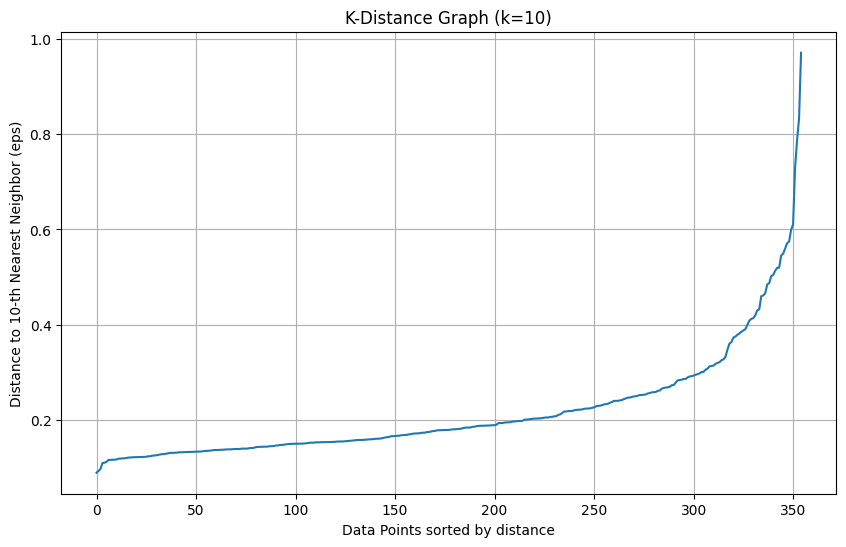

In [300]:
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title(f'K-Distance Graph (k={min_samples})')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}-th Nearest Neighbor (eps)')
plt.grid(True)
plt.show()

In [316]:
# print(k_distances[340:])
# Use eps = 0.35
eps = 0.35

In [317]:
dbs = DBSCAN(min_samples=min_samples, eps=eps)
model_dbs = dbs.fit(df_final)
df_final['cluster'] = model_dbs.labels_

df_final['cluster'].value_counts()

cluster
 0    246
-1     57
 1     41
 2     11
Name: count, dtype: int64

In [332]:
df_final.corr()

name,นางสาววิชุดา ว่องวัฒนวิโรจน์_normalize,นางสาวสุวิภา กุศลจูง_normalize,นายศรีพรหม หอมยก_normalize,นายสมบูรณ์ รูปสะอาด_normalize,นายดาชัย เอกปฐพี_normalize,นายธนาธร โล่ห์สุนทร_normalize,พันเอกสันทัด ภัทรกิตตินนท์_normalize,ไทยทรัพย์ทวี_normalize,เพื่อชาติไทย_normalize,ใหม่_normalize,...,ไทยก้าวใหม่_normalize,ประชาอาสาชาติ_normalize,พร้อม_normalize,เครือข่ายชาวนาแห่งประเทศไทย_normalize,ไทยพิทักษ์ธรรม_normalize,ความหวังใหม่_normalize,ไทยรวมไทย_normalize,เพื่อบ้านเมือง_normalize,พลังไทยรักชาติ_normalize,cluster
name,,,,,,,,,,,,,,,,,,,,,
นางสาววิชุดา ว่องวัฒนวิโรจน์_normalize,1.000000,0.163680,0.318853,0.167898,-0.355092,0.151277,0.004046,0.114200,0.024922,-0.010767,...,-0.026101,0.039879,0.061923,0.007394,-0.062227,0.044174,-0.039492,0.070245,-0.043334,-0.067274
นางสาวสุวิภา กุศลจูง_normalize,0.163680,1.000000,0.302159,0.176974,-0.724348,0.161598,0.045203,-0.035558,0.006210,-0.047379,...,-0.029309,-0.045783,-0.035874,-0.013215,-0.100608,0.037096,-0.049789,-0.069918,0.089828,0.394833
นายศรีพรหม หอมยก_normalize,0.318853,0.302159,1.000000,0.301977,-0.478491,0.192152,0.036928,0.019011,0.101202,-0.053669,...,-0.041900,-0.022825,0.080334,-0.048047,-0.015579,0.078213,-0.028717,-0.011150,-0.008741,-0.015908
นายสมบูรณ์ รูปสะอาด_normalize,0.167898,0.176974,0.301977,1.000000,-0.309839,0.100067,0.032418,0.143576,0.110786,-0.009116,...,-0.024586,-0.027708,-0.037957,-0.054407,-0.031231,0.044001,-0.022146,-0.027720,-0.066265,-0.031943
นายดาชัย เอกปฐพี_normalize,-0.355092,-0.724348,-0.478491,-0.309839,1.000000,-0.628086,-0.251520,-0.023233,-0.073123,0.077632,...,0.052712,0.039513,0.033283,0.080468,0.111672,-0.058053,0.090868,0.044848,-0.094227,-0.108458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ความหวังใหม่_normalize,0.044174,0.037096,0.078213,0.044001,-0.058053,0.047725,-0.025275,-0.007241,0.009147,-0.011153,...,0.009023,-0.007372,0.017385,0.045260,0.062555,1.000000,0.093332,0.122309,-0.001970,-0.097489
ไทยรวมไทย_normalize,-0.039492,-0.049789,-0.028717,-0.022146,0.090868,-0.071915,-0.034240,0.001481,-0.027018,0.028485,...,-0.018422,-0.011947,0.219250,0.598284,0.795900,0.093332,1.000000,0.898230,0.045761,0.059764
เพื่อบ้านเมือง_normalize,0.070245,-0.069918,-0.011150,-0.027720,0.044848,-0.011533,0.021441,0.028476,-0.022617,-0.012135,...,-0.030022,0.002976,0.222528,0.566526,0.751183,0.122309,0.898230,1.000000,0.024799,0.032492


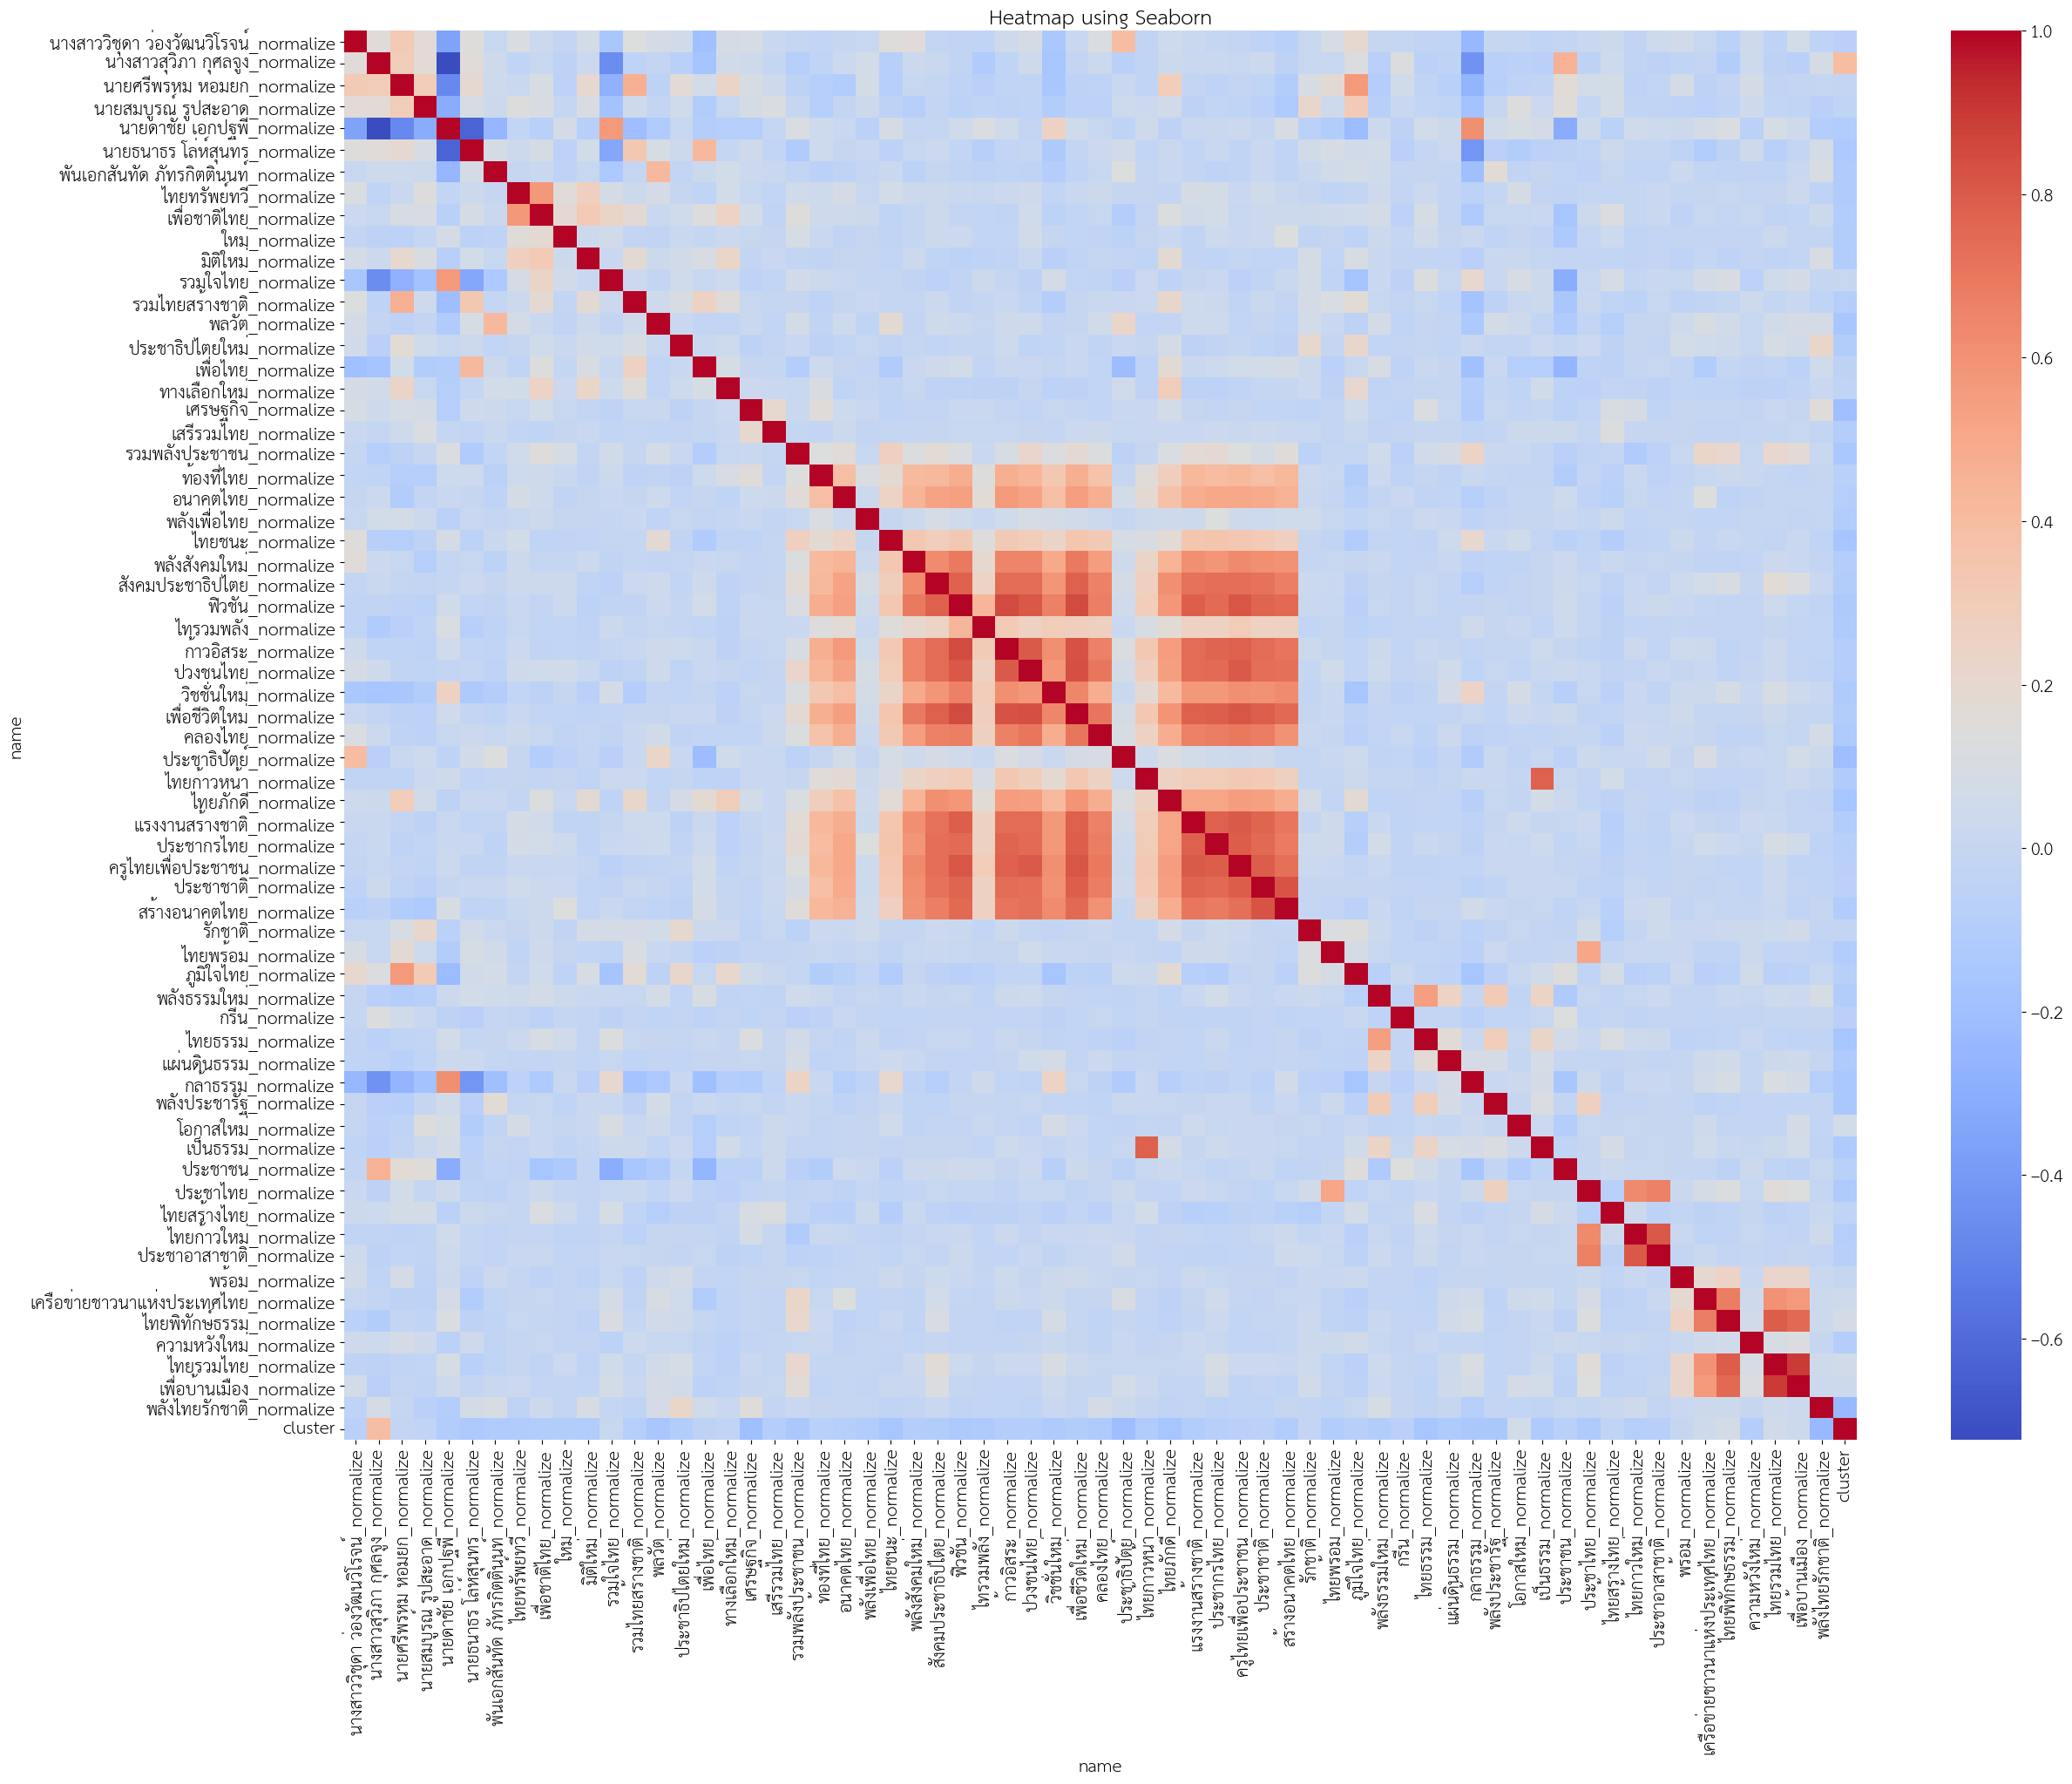

In [333]:
plt.figure(figsize=(28,21))

sns.heatmap(df_final.corr(),cmap='coolwarm')

plt.title("Heatmap using Seaborn")
plt.show()

In [335]:
tsne = TSNE(n_components=2, perplexity=30, random_state=1)
df_tsne = tsne.fit_transform(df_final[norm_cols])

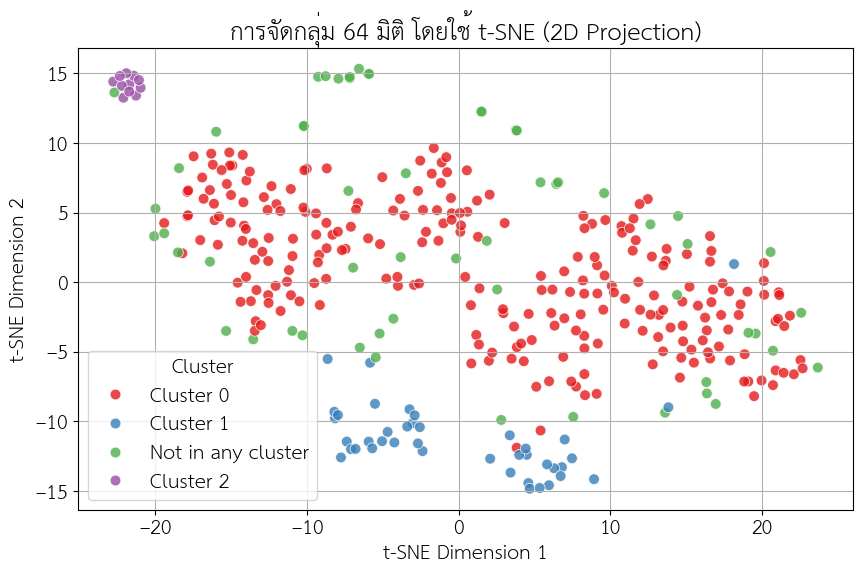

In [338]:
cluster2name = {
    -1: "Not in any cluster",
    0: "Cluster 0", 
    1: "Cluster 1",
    2: "Cluster 2",
}
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_tsne[:, 0], y=df_tsne[:, 1], hue=df_final['cluster'].map(cluster2name), palette='Set1', s=60, alpha=0.8)

plt.title('การจัดกลุ่ม 64 มิติ โดยใช้ t-SNE (2D Projection)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()